Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor # Decision tree kind of Predicting algorithm [XGBRegressor - For predicting(classify) continuous numeric values ; XGBClassifier - For predicting(classify) 0s and 1s]
from sklearn import metrics
from sklearn.metrics import accuracy_score

Importing the California House price dataset

In [2]:
house_price_dataset = sklearn.datasets.fetch_california_housing()

In [3]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [4]:
#Loading the dataset to a pandas dataframe
house_price_dataframe = pd.DataFrame(house_price_dataset.data, columns = house_price_dataset.feature_names)

In [5]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
#add the target column to the dataframe
house_price_dataframe['Price'] = house_price_dataset.target

In [7]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
house_price_dataframe.shape

(20640, 9)

In [9]:
#missing values
house_price_dataframe.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [10]:
house_price_dataframe.describe() #statistical measures

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Understanding the correlation between various features in the dataset

1. Positive Correlation (if one value increases another value also increases)
2. Negative Correlation (vise versa)

In [11]:
correlation = house_price_dataframe.corr()

<Axes: >

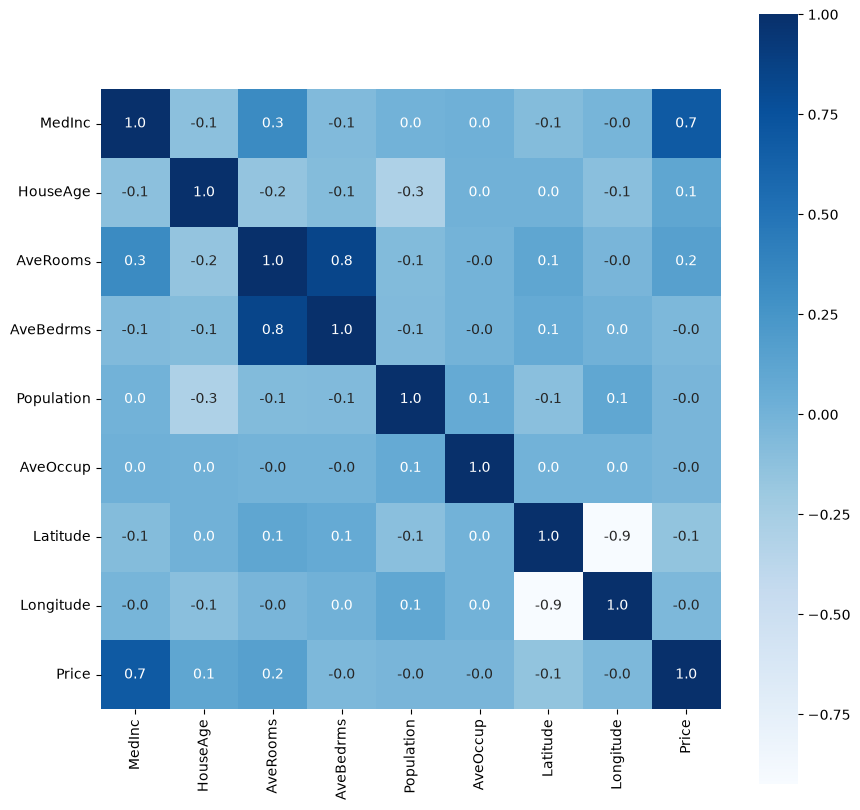

In [12]:
#constructing the heat map
plt.figure(figsize = (10,10))
#correlation-our value need to present, cbar-colorBar on right side, square-all values are mentioned in squares, fmt .1f-values with one decimal point, annot-annotating the feature names, annot_kws-value's size, cmap-colormap
sns.heatmap(correlation, cbar = True, square = True, fmt = '.1f', annot=True, annot_kws={'size':10}, cmap = 'Blues')
# dark color - positively correlated ; light color - negatively correlated

In [13]:
#splitting the data and labels
X = house_price_dataframe.drop(['Price'], axis = 1) #axis=1 is for representing the column
Y = house_price_dataframe['Price']
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

Train_Test_Split

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(20640, 8) (16512, 8) (4128, 8)


Model Training

XGBoost Regressor

In [15]:
#loading the model
model = XGBRegressor()

In [16]:
#training the model with X_train
model.fit(X_train, Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Evaluation

In [17]:
#Make predictions on the train data
training_data_prediction = model.predict(X_train)
print(training_data_prediction)

[0.53758794 2.9007688  0.6848911  ... 1.7890452  1.9554564  0.7771621 ]


In [18]:
# Make predictions on the test data
testing_data_prediction = model.predict(X_test)
print(testing_data_prediction)

[2.880331   1.8918151  0.923897   ... 1.5574043  0.82967275 1.9735563 ]


In [19]:
# ERROR FOR TRAINING DATA by the Model
# R squared error
score_1 = metrics.r2_score(Y_train, training_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print("R squared error :", score_1) # R-squared values closer to 1 indicate a better fit
print('Mean Absolute Error :', score_2) # lower MAE values indicate smaller prediction errors. (if it's value is near 5 or 10 model made wrong prediction)

R squared error : 0.947186443380359
Mean Absolute Error : 0.18885009247854148


<function matplotlib.pyplot.show(close=None, block=None)>

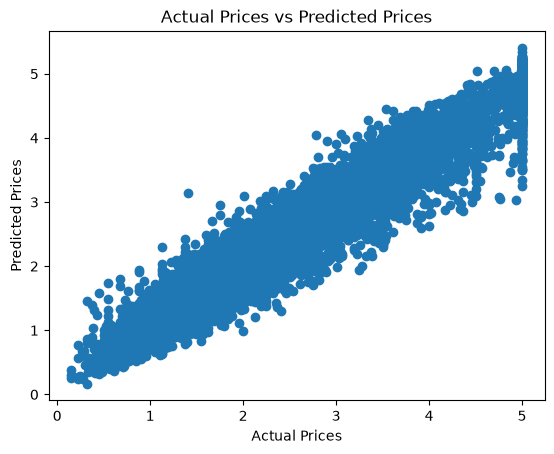

In [20]:
#Visualizing the actual prices for train data
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show

In [21]:
# ERROR FOR TESTING DATA by the Model
# R squared error
score_1 = metrics.r2_score(Y_test, testing_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test, testing_data_prediction)

print("R squared error :", score_1)
print('Mean Absolute Error :', score_2)

R squared error : 0.8370813165448978
Mean Absolute Error : 0.3079223702763229


<function matplotlib.pyplot.show(close=None, block=None)>

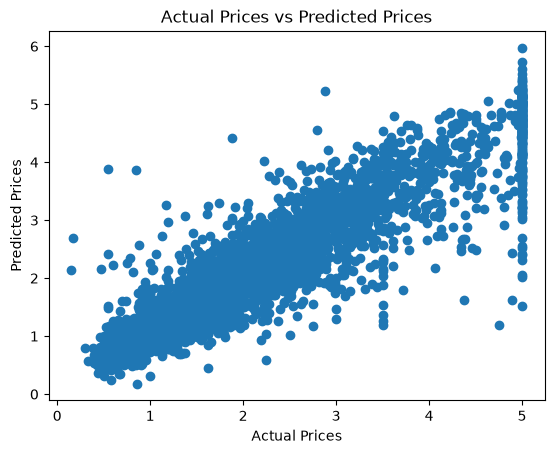

In [22]:
#Visualizing the actual prices for test data
plt.scatter(Y_test, testing_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show

The close alignment of actual and predicted price points in the graph shows that the model performs well.

In [23]:
'''
In House Price , the dataset is taken from the Scikit learn (sklearn.datasets) fetch_california_housing() ,
And then the numeric dataset is converted to dataframe by the help of pandas, then the statistical measures have 
been measured (describe) . The correlation factor is applied to understand the correlation between various features
in the dataset, the values are the plotted in square box (heatmap) to analyse the dataset is in positive or 
negative correlation. The Labels and data are seperated by the variables Y and X respectively. 
The variable X and Y undergoes train_test_split process to train the data. 
And the XGBRegressor model is used to train the model (XGBRegressor predicts house prices by combining many 
small decision trees that learn from past mistakes. It is used because it handles complex patterns and gives 
more accurate results than simple models.), that model is fitted to the trained dataset, 
model.predict will predict the house price , 

Training dataset prediction = [0.5523039 3.0850039 0.5835302 ... 1.9204227 1.952873 0.6768683] 
Testing dataset prediction = [2.8649795 1.790346 0.92074925 ... 1.5385513 0.92647874 2.043316 ]

And then Evaluation is done using R-squared and Mean Absolute Error to measure how well the model predicts 
house prices on training and testing data. R-squared values closer to 1 indicate a better fit, 
while lower MAE values indicate smaller prediction errors. 
The close alignment of actual and predicted price points in the graph shows that the model performs well.

Training data : R squared error : 0.943650140819218 Mean Absolute Error : 0.1933648700612105
'''

'\nIn House Price , the dataset is taken from the Scikit learn (sklearn.datasets) fetch_california_housing() ,\nAnd then the numeric dataset is converted to dataframe by the help of pandas, then the statistical measures have \nbeen measured (describe) . The correlation factor is applied to understand the correlation between various features\nin the dataset, the values are the plotted in square box (heatmap) to analyse the dataset is in positive or \nnegative correlation. The Labels and data are seperated by the variables Y and X respectively. \nThe variable X and Y undergoes train_test_split process to train the data. \nAnd the XGBRegressor model is used to train the model (XGBRegressor predicts house prices by combining many \nsmall decision trees that learn from past mistakes. It is used because it handles complex patterns and gives \nmore accurate results than simple models.), that model is fitted to the trained dataset, \nmodel.predict will predict the house price , \n\nTraining da